In [1]:
!pip install numpy matplotlib graphviz

In [18]:
from dataclasses import dataclass
import numpy as np
from typing import Any, List, Callable
from collections import defaultdict

@dataclass(frozen=True)
class Step:
    action: Any
    reward: float # Reward R(s, a, s')
    prob: float # State transition probability T(s, a, s')
    state: Any # Next state s'

class MDP:
    def start_state(self) -> Any:
        raise NotImplementedError
    
    def successors(self, state: Any) -> List[Step]:
        raise NotImplementedError

    def is_end(self, state: Any) -> bool:
        raise NotImplementedError

    def discount(self) -> float:
        raise NotImplementedError

# Policy: map state (input) to action (output)
Policy = Callable[[Any], Any]


In [ ]:
class FlackyTramMDP(MDP):
    def __init__(self, num_locs: int = 20, failure_prob: float = 0.4):
        self.num_locs = num_locs
        self.failure_prob = failure_prob

    def start_state(self) -> int:
        return 1

    def successors(self, state: int) -> List[Step]:
        steps = []
        # Action 1: walk (takes 1 min, reward -1, 100% success)
        if state + 1 <= self.num_locs:
            steps.append(Step(action="walk", reward=-1.0, prob=1.0, state=state+1))
        # Action 2: tram (takes 2 min, reward -2, 60% success)
        if state * 2 <= self.num_locs:
            steps.append(Step(action="tram", reward=-2, prob=1-self.failure_prob, state=state * 2))
            steps.append(Step(action="tram", reward=-2, prob=self.failure_prob, state=state))
        else:
            #Invalid action, add penalty -100, end at last stop
            steps.append(Step(action="tram", reward=-100, prob=1, state=self.num_locs))
        return steps

    def is_end(self, state: int) -> bool:
        return state == self.num_locs

    def discount(self) -> float:
        return 0.9


class DiceGameMDP(MDP):
    def start_state(self) -> str:
        return "in"

    def is_end(self, state: str) -> bool:
        return state == "end"
    
    def discount(self) -> float:
        return 1

    def successors(self, state: str) -> List[Step]:
        if state == 'end':
            return []
        return [
            Step(action="quit", reward=10.0, prob=1, state="end"),
            Step(action="stay", reward=4.0, prob=1/3, state="end"),
            Step(action="stay", reward=4.0, prob=2/3, state="in")
        ]


In [9]:
# ============= Monte Carlo Policy Evaluation ================
# Run multiple rollouts with the policy and compute average utility

@dataclass(frozen=True)
class Rollout:
    steps: List[Step]
    discount: float
    utility: float

def generate_rollout(mdp: MDP, policy: Policy) -> Rollout:
    state = mdp.start_state()
    steps = []
    while not mdp.is_end(state):
        action = policy(state)
        successors = [step for step in mdp.successors(state) if step.action == action]
        probs = [step.prob for step in successors]
        choice = np.random.choice(len(successors), p=probs)
        step = successors[choice]
        steps.append(step)
        state = step.state
    return Rollout(
        steps=steps, 
        discount=mdp.discount(), 
        utility=compute_utility(steps, mdp.discount()))

def compute_utility(steps: List[Step], discount: float) -> float:
    # discounted reward
    return sum(step.reward * discount ** i for i, step in enumerate(steps))

def monte_carlo_policy_evaluation(mdp: MDP, policy: Policy, num_rollouts: int) -> float:
    utilities = [generate_rollout(mdp, policy).utility for _ in range(num_rollouts)]
    return float(np.mean(utilities))

# Test monte carlo policy evaluation
tram_mdp = FlackyTramMDP(num_locs=10, failure_prob=0.4)
walk_policy = lambda s: "walk"
tram_policy = lambda s: "tram" if s * 2 <= tram_mdp.num_locs else "walk"
walk_eval = monte_carlo_policy_evaluation(tram_mdp, walk_policy, 1)
tram_eval = monte_carlo_policy_evaluation(tram_mdp, tram_policy, 100)
print("walk:", walk_eval, "tram: ", tram_eval)

walk: -9.0 tram:  -12.6


{1: -12.000003401174734, 2: -8.66666684320477, 3: -7.333333360999696, 4: -5.333333337749863, 5: -3.3333333340298896, 6: -4.0, 7: -3.0, 8: -2.0, 9: -1.0, 10: 0}


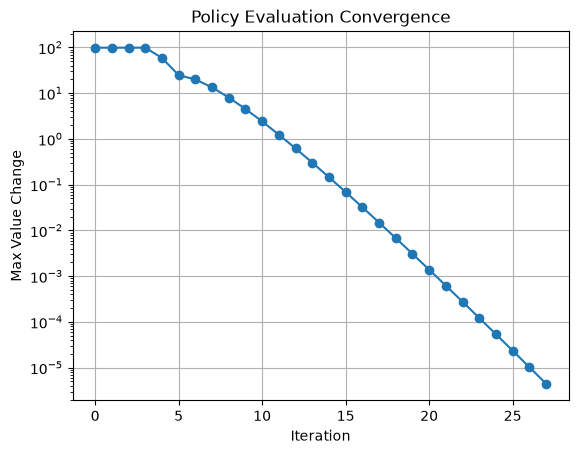

In [20]:
import matplotlib.pyplot as plt

#=============== Policy Evaluation w/o Rollout =========================

def get_states(mdp: MDP) -> List[Any]:
    states = set()
    def next_state(state):
        if state in states:
            return
        states.add(state)
        for step in mdp.successors(state):
            next_state(step.state)

    next_state(mdp.start_state())
    return list(states)

def initial_values(mdp: MDP, states: List[Any]) -> dict:
    return {s: 0 if mdp.is_end(s) else -100 for s in states}

def compute_q_value(values: dict[Any, float], steps: List[Step], discount: float) -> float:
    # compute Q(s, a) = ∑ T(s,a,s') * [R(s,a,s') + γ * V(s')]
    return sum(step.prob * (step.reward + discount * values[step.state]) for step in steps)

def compute_distance(values: dict, next_values: dict) -> float:
    return max([abs(values[s] - next_values[s]) for s in values.keys()])

def policy_evaluation(mdp: MDP, policy: Policy, max_iters: int =100, tolerance: float = 1e-5) -> tuple[dict[Any, float], List[float]]:
    states = get_states(mdp)
    values = initial_values(mdp, states)
    distances = []
    for _ in range(max_iters):
        next_values = {}
        for state in states:
            if mdp.is_end(state):
                next_values[state] = 0
                continue
            action = policy(state)
            steps = [step for step in mdp.successors(state) if step.action == action]
            next_values[state] = compute_q_value(values, steps, mdp.discount())
        distance = compute_distance(values, next_values)
        distances.append(distance)
        values = next_values
        if distance < tolerance:
            break
    return values, distances

def draw_evaluation_convergence(distances: List[float]):
    plt.plot(distances, marker='o')
    plt.title("Policy Evaluation Convergence")
    plt.xlabel("Iteration")
    plt.ylabel("Max Value Change")
    plt.yscale('log')
    plt.grid(True)
    plt.show()

# Test and draw converge diagram
values, distances = policy_evaluation(tram_mdp, tram_policy)
#values, distances = policy_evaluation(tram_mdp, walk_policy)
print(values)
draw_evaluation_convergence(distances)



{1: -7.3333399762160845, 2: -6.333335990486434, 3: -5.333334396194574, 4: -4.3333337584778295, 5: -3.333333503391132, 6: -4.0, 7: -3.0, 8: -2.0, 9: -1.0, 10: 0}
{1: 'walk', 2: 'walk', 3: 'walk', 4: 'walk', 5: 'tram', 6: 'walk', 7: 'walk', 8: 'walk', 9: 'walk', 10: None}
[99.0, 98.0, 97.0, 96.0, 27.28, 19.520000000000003, 9.280000000000003, 3.7120000000000015, 1.4848, 0.5939199999999998, 0.23756800000000045, 0.09502719999999965, 0.03801087999999986, 0.015204352000000476, 0.006081740800000013, 0.00243269631999965, 0.0009730785280002152, 0.0003892314111997308, 0.00015569256447989233, 6.22770257923122e-05, 2.4910810316747245e-05, 9.964324126698898e-06]


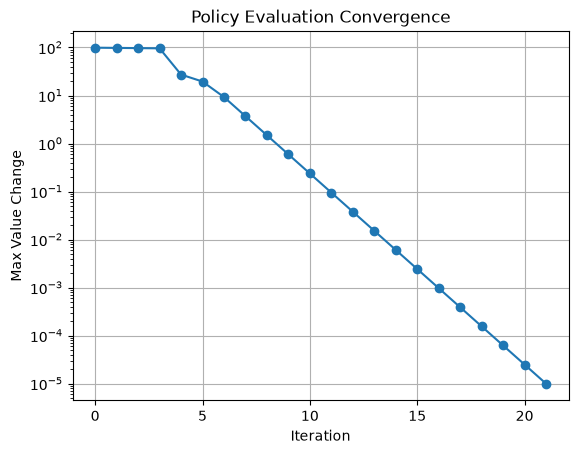

In [26]:
#=============== Value Evaluation for Optimal Policy =========================

def get_action_successors(mdp: MDP, state: Any) -> dict[Any, List[Step]]:
    action_to_successors = defaultdict(list)
    for step in mdp.successors(state):
        action_to_successors[step.action].append(step)
    return action_to_successors

def value_iteration_for_state(mdp: MDP, state: Any, values: dict[Any, float]) -> tuple[float, Any]:
    actions = []
    utilities = []
    for action, steps in get_action_successors(mdp, state).items():
        actions.append(action)
        utilities.append(compute_q_value(values, steps, mdp.discount()))
    return max(utilities), actions[np.argmax(utilities)]

def value_evaluation(mdp: MDP, max_iters: int = 100, tolerance: float = 1e-5):
    states = get_states(mdp)
    values = initial_values(mdp, states)
    distances = []
    pi = {s: None for s in states}
    for _ in range(max_iters):
        next_values = {}
        for s in states:
            if mdp.is_end(s):
                next_values[s] = 0
                continue
            val, action = value_iteration_for_state(mdp, s, values)
            next_values[s] = val
            pi[s] = action
        distance = compute_distance(values, next_values)
        distances.append(distance)
        values = next_values
        if distance < tolerance:
            break
    return values, pi, distances

# Test value evaluation
values, best_policy, distances = value_evaluation(tram_mdp)
print(values)
print(best_policy)
print(distances)
draw_evaluation_convergence(distances)


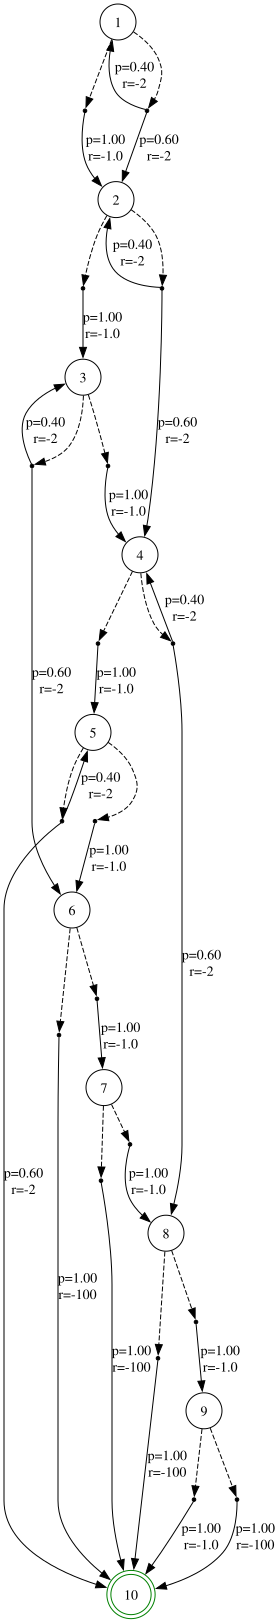

In [29]:
from graphviz import Digraph

def draw_mdp_graph(mdp: MDP):
    dot = Digraph(comment="MDP Graph")
    visited = set()
    def recurse(state):
        if state in visited:
            return
        visited.add(state)

        if mdp.is_end(state):
            dot.node(str(state), shape="doublecircle", color="green")
        else:
            dot.node(str(state), shape='circle')
            action_to_steps = defaultdict(list)
            for successor in mdp.successors(state):
                action_to_steps[successor.action].append(successor)
            for action, steps in action_to_steps.items():
                act_node_id = f"{state}_{action}"
                dot.node(act_node_id,label=action, shape="point")
                dot.edge(str(state), act_node_id, style="dashed")

                for step in steps:
                    label = f"p={step.prob:.2f}\nr={step.reward}"
                    dot.edge(act_node_id, str(step.state), label=label)
                    recurse(step.state)
    recurse(mdp.start_state())
    return dot

draw_mdp_graph(tram_mdp)